<a href="https://colab.research.google.com/github/kanvesh/python_tutorial_workbooks/blob/master/timeseries_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
import matplotlib.pyplot as plt

In [86]:
df = pd.read_csv('synthetic_delinquency_2022_2025_low_trend_monthly.csv')

In [87]:
df.shape

(1461, 6)

In [88]:
df.head()


,as_at_date,delinquency_rate,day_of_week,month,quarter,week_of_year
0,2022-01-01,0.13471,Saturday,1,1,52
1,2022-01-02,0.14193,Sunday,1,1,52
2,2022-01-03,0.15749,Monday,1,1,1
3,2022-01-04,0.14756,Tuesday,1,1,1
4,2022-01-05,0.15583,Wednesday,1,1,1


In [89]:
df = df.rename(columns={'as_at_date': 'date'})
df['date'] = pd.to_datetime(df['date'])
df.head()

,date,delinquency_rate,day_of_week,month,quarter,week_of_year
0,2022-01-01,0.13471,Saturday,1,1,52
1,2022-01-02,0.14193,Sunday,1,1,52
2,2022-01-03,0.15749,Monday,1,1,1
3,2022-01-04,0.14756,Tuesday,1,1,1
4,2022-01-05,0.15583,Wednesday,1,1,1


In [90]:
df["year"] = df["date"].dt.year
df["time_index"] = np.arange(len(df)) #adding a new column 'time_index'.. its just 0,1,2,3,4 etc. assigned from the earliest day to the last

In [91]:
df.head()

,date,delinquency_rate,day_of_week,month,quarter,week_of_year,year,time_index
0,2022-01-01,0.13471,Saturday,1,1,52,2022,0
1,2022-01-02,0.14193,Sunday,1,1,52,2022,1
2,2022-01-03,0.15749,Monday,1,1,1,2022,2
3,2022-01-04,0.14756,Tuesday,1,1,1,2022,3
4,2022-01-05,0.15583,Wednesday,1,1,1,2022,4


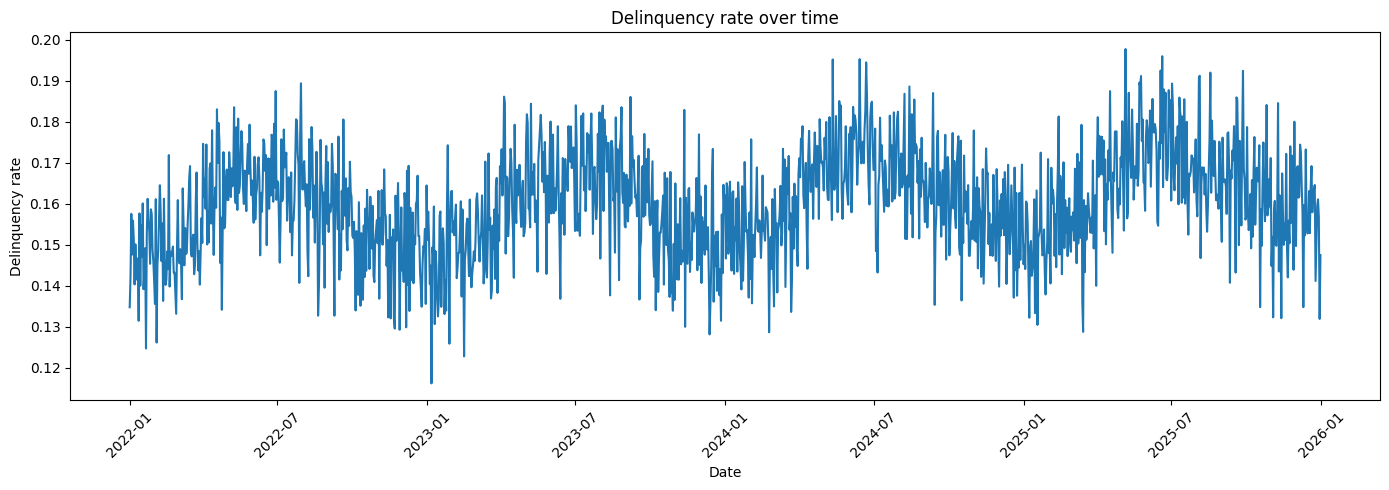

In [92]:
plt.figure(figsize=(14, 5))

plt.plot(df["date"], df["delinquency_rate"])

plt.xlabel("Date")
plt.ylabel("Delinquency rate")
plt.title("Delinquency rate over time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#just to eyeball the trend

In [93]:
df.groupby("year")["delinquency_rate"].agg(
    ["mean", "std", "count"]
)

#eyeballing

,mean,std,count
year,,,
2022,0.156516,0.012231,365
2023,0.158027,0.013061,365
2024,0.162094,0.012001,366
2025,0.163356,0.012944,365


In [94]:
df.groupby("day_of_week")["delinquency_rate"].agg(
    ["mean", "std", "count"]
)
#eyeballing

,mean,std,count
day_of_week,,,
Friday,0.159808,0.013353,208
Monday,0.159547,0.012275,209
Saturday,0.159580,0.013439,209
Sunday,0.160036,0.012749,209
Thursday,0.159791,0.012587,208
Tuesday,0.160202,0.013244,209
Wednesday,0.161033,0.012488,209


In [95]:
df.groupby("quarter")["delinquency_rate"].agg(
    ["mean", "std", "count"]
)
#eyeballing

,mean,std,count
quarter,,,
1,0.151598,0.010243,361
2,0.168464,0.010382,364
3,0.165681,0.010945,368
4,0.154189,0.011066,368


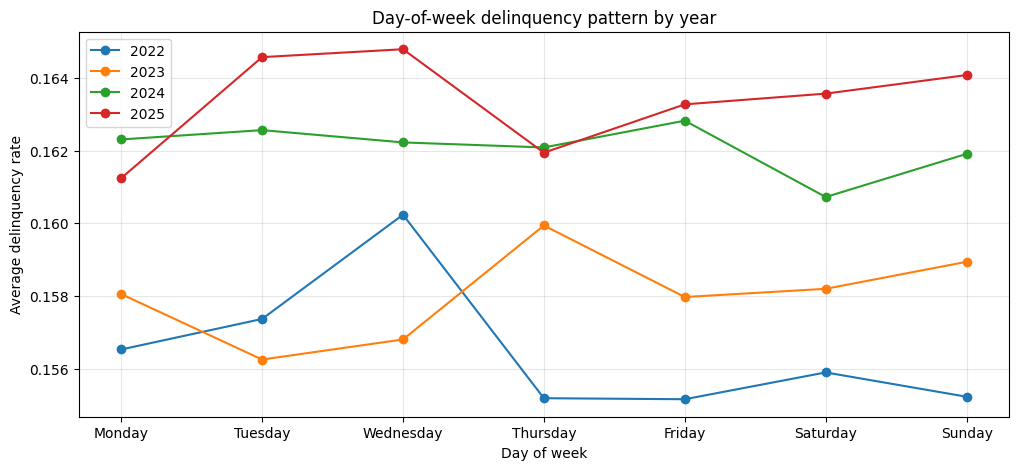

In [96]:
#plotting by day_of_week

dow_year = (
    df.groupby(["year", "day_of_week"])["delinquency_rate"]
      .mean()
      .reset_index()
)

# Put days in calendar order
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

dow_year["day_of_week"] = pd.Categorical(
    dow_year["day_of_week"],
    categories=day_order,
    ordered=True
)

dow_year = dow_year.sort_values("day_of_week")

plt.figure(figsize=(12, 5))

for year in sorted(dow_year["year"].unique()):
    temp = dow_year[dow_year["year"] == year]
    plt.plot(
        temp["day_of_week"],
        temp["delinquency_rate"],
        marker="o",
        label=str(year)
    )

plt.xlabel("Day of week")
plt.ylabel("Average delinquency rate")
plt.title("Day-of-week delinquency pattern by year")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

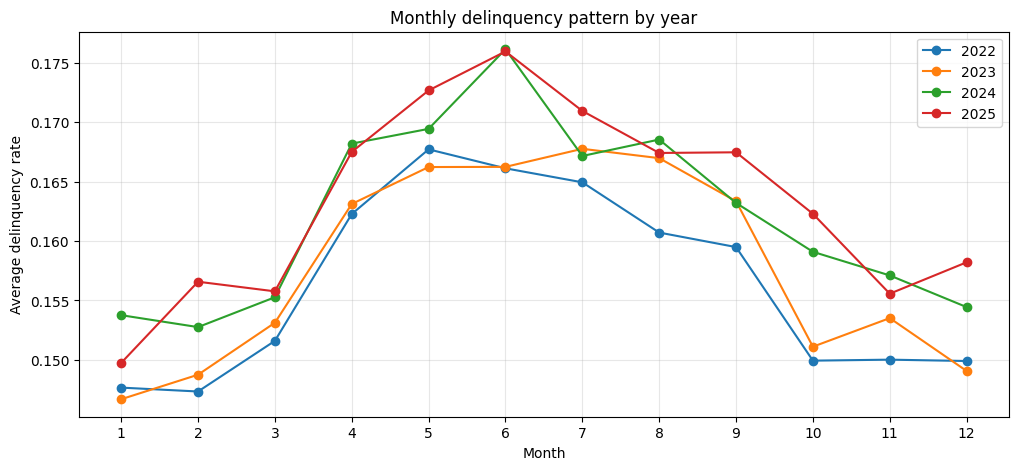

In [97]:
#plotting by month

month_year = (
    df.groupby(["year", "month"])["delinquency_rate"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(12, 5))

for year in sorted(month_year["year"].unique()):
    temp = month_year[month_year["year"] == year]
    plt.plot(
        temp["month"],
        temp["delinquency_rate"],
        marker="o",
        label=str(year)
    )

plt.xlabel("Month")
plt.ylabel("Average delinquency rate")
plt.title("Monthly delinquency pattern by year")
plt.xticks(range(1, 13))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

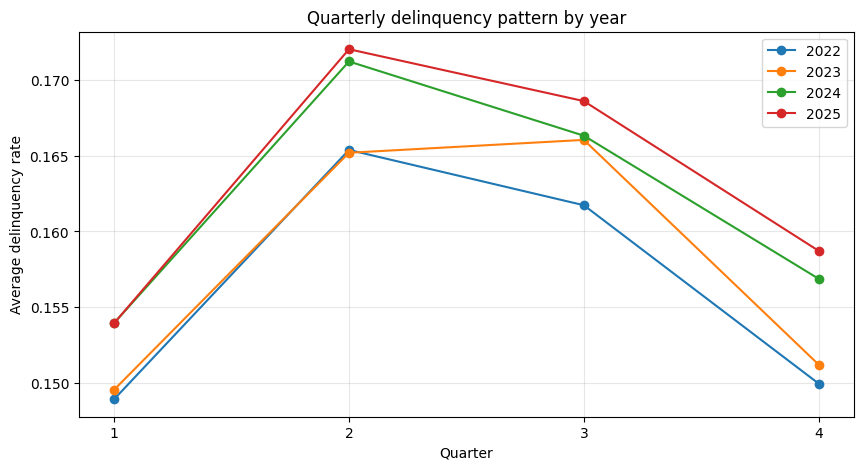

In [98]:
#plotting by quarter

quarter_year = (
    df.groupby(["year", "quarter"])["delinquency_rate"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10, 5))

for year in sorted(quarter_year["year"].unique()):
    temp = quarter_year[quarter_year["year"] == year]
    plt.plot(
        temp["quarter"],
        temp["delinquency_rate"],
        marker="o",
        label=str(year)
    )

plt.xlabel("Quarter")
plt.ylabel("Average delinquency rate")
plt.title("Quarterly delinquency pattern by year")
plt.xticks([1, 2, 3, 4])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

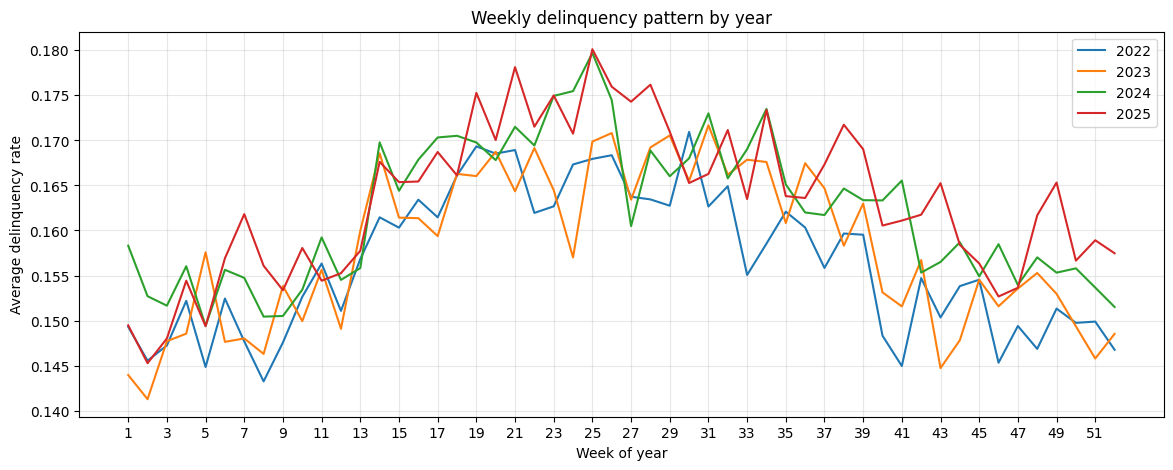

In [99]:
#plotting by week_of_year

weekly_year = (
    df.groupby(["year", "week_of_year"])["delinquency_rate"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(14, 5))

for year in sorted(weekly_year["year"].unique()):
    temp = weekly_year[weekly_year["year"] == year]
    plt.plot(
        temp["week_of_year"],
        temp["delinquency_rate"],
        label=str(year)
    )

plt.xlabel("Week of year")
plt.ylabel("Average delinquency rate")
plt.title("Weekly delinquency pattern by year")
plt.xticks(range(1, 53, 2))
plt.legend()
plt.grid(alpha=0.3)


In [100]:
#is this variable alone explanatory? Look at the P value. Also higher F is better

model = smf.ols(
    "delinquency_rate ~ C(day_of_week)",
    data=df
).fit()

print(sm.stats.anova_lm(model, typ=2))

                  sum_sq      df         F    PR(>F)
C(day_of_week)  0.000328     6.0  0.329426  0.921717
Residual        0.241341  1454.0       NaN       NaN


In [101]:
#is this variable alone explanatory? Look at the P value. Also higher F is better

model = smf.ols(
    "delinquency_rate ~ C(month)",
    data=df
).fit()

print(sm.stats.anova_lm(model, typ=2))

            sum_sq      df          F         PR(>F)
C(month)  0.080817    11.0  66.183397  8.638919e-120
Residual  0.160852  1449.0        NaN            NaN


In [102]:
#is this variable alone explanatory? Look at the P value. Also higher F is better

model = smf.ols(
    "delinquency_rate ~ C(quarter)",
    data=df
).fit()

print(sm.stats.anova_lm(model, typ=2))

              sum_sq      df           F         PR(>F)
C(quarter)  0.075864     3.0  222.214893  1.081687e-118
Residual    0.165805  1457.0         NaN            NaN


In [103]:
#is this variable alone explanatory? Look at the P value. Also higher F is better

model = smf.ols(
    "delinquency_rate ~ C(week_of_year)",
    data=df
).fit()

print(sm.stats.anova_lm(model, typ=2))

                   sum_sq      df          F        PR(>F)
C(week_of_year)  0.082782    51.0  14.394184  6.197003e-95
Residual         0.158887  1409.0        NaN           NaN


In [104]:
#lets see how much trend alone explains

trend_model = smf.ols(
    "delinquency_rate ~ time_index",
    data=df
).fit()

print(trend_model.rsquared)

0.047360108064917306


In [105]:
#does this variable add anything after accounting for trend (time_index)

month_model = smf.ols(
    "delinquency_rate ~ time_index + C(month)",
    data=df
).fit()

print(month_model.rsquared)

0.3801198646154553


In [106]:
#incremental R2 tells us what the variable adds after accounting for trend

print("Trend R²:", trend_model.rsquared)
print("Trend + Month R²:", month_model.rsquared)

print("Incremental R²:",
      month_model.rsquared - trend_model.rsquared)

Trend R²: 0.047360108064917306
Trend + Month R²: 0.3801198646154553
Incremental R²: 0.332759756550538


In [107]:
#looping the same for all variables

variables = [
    "day_of_week",
    "month",
    "quarter",
    "week_of_year"
]

results = []

for var in variables:

    model = smf.ols(
        f"delinquency_rate ~ time_index + C({var})",
        data=df
    ).fit()

    comparison = sm.stats.anova_lm(
        trend_model,
        model
    )

    results.append({
        "variable": var,
        "p_value": comparison.iloc[1]["Pr(>F)"],
        "r2": model.rsquared,
        "incremental_r2": (
            model.rsquared - trend_model.rsquared
        )
    })

results_df = pd.DataFrame(results)

print(results_df)

       variable        p_value        r2  incremental_r2
0   day_of_week   9.177147e-01  0.048683        0.001323
1         month  9.844269e-127  0.380120        0.332760
2       quarter  2.737090e-125  0.360089        0.312729
3  week_of_year  1.257273e-101  0.388341        0.340980


In [108]:
#this is to account for second order interactions
# does the combinations of year and month account for anything more than just having year and month as separate variables in the model
#high level stuff. can be ignored.


model = smf.ols(
    "delinquency_rate ~ C(year) + C(month)",
    data=df
).fit()

interaction_model = smf.ols(
    "delinquency_rate ~ C(year) * C(month)",
    data=df
).fit()

print(sm.stats.anova_lm(
    model,
    interaction_model
))

   df_resid       ssr  df_diff   ss_diff         F    Pr(>F)
0    1446.0  0.149249      0.0       NaN       NaN       NaN
1    1413.0  0.145095     33.0  0.004154  1.225779  0.178147


In [109]:
# here I am testing if year adds anything after trend and month are accounted for


model1 = smf.ols(
 f"delinquency_rate ~ time_index + C(month)",
 data=df
).fit()

model2 = smf.ols(
 f"delinquency_rate ~ time_index + C(month) + C(year)",
 data=df
).fit()

results = []
comparison = sm.stats.anova_lm(
model1,
model2
)

results.append({
  "p_value": comparison.iloc[1]["Pr(>F)"],
  "r2": model2.rsquared,
  "incremental_r2": (
      model2.rsquared - model1.rsquared
)
})

results_df = pd.DataFrame(results)

print(results_df)

    p_value        r2  incremental_r2
0  0.143686  0.382439        0.002319
